# Low-Dose CT Denoising with RED-CNN
- Denoises simulated quarter-dose CT slices toward full-dose quality using RED-CNN (Chen et al., 2017, arXiv:1702.00288), trained on the 2016 NIH-AAPM-Mayo Clinic Low Dose CT Grand Challenge dataset.
- Full design rationale, results, and known limitations: see README.md.
- Requires: torch, pydicom, numpy, pandas, scikit-image, matplotlib. Run with the andrewmvd/ct-low-dose-reconstruction dataset attached. pydicom is not always preinstalled on Kaggle's GPU image -- if the import below fails, run `pip install pydicom` first.

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import pydicom
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage.filters import gaussian as gaussian_filter
import matplotlib.pyplot as plt

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Locate the dataset

In [2]:
ORIG_ROOT = (Path("/kaggle/input/datasets/andrewmvd/ct-low-dose-reconstruction")
             / "CT_low_dose_reconstruction_dataset" / "Original Data")

if not ORIG_ROOT.exists():
    raise FileNotFoundError(
        f"Expected the dataset at {ORIG_ROOT}, but it's not there. Run "
        "os.listdir('/kaggle/input') (and subfolders) to find where it landed "
        "this run, then update ORIG_ROOT above."
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dataset found:", ORIG_ROOT)
print("Device:", device)

Dataset found: /kaggle/input/datasets/andrewmvd/ct-low-dose-reconstruction/CT_low_dose_reconstruction_dataset/Original Data
Device: cuda


## Config
- Dataset paths, HU window, and the fixed 7/1/2 patient split.

In [3]:
THICKNESS = "1mm Slice Thickness"
KERNEL = "Sharp Kernel (D45)"
HU_WINDOW = (-160, 240)   # standard abdominal soft-tissue window (WL 40 / WW 400)
PATCH_SIZE = 64

TRAIN_PATIENTS = ["L067", "L096", "L109", "L143", "L192", "L286", "L291"]
VAL_PATIENTS   = ["L310"]
TEST_PATIENTS  = ["L333", "L506"]

# Non-local means takes a few seconds per 512x512 slice, so the classical
# baseline comparison below runs on a subsample of the test set rather than
# all 1136 slices -- a real runtime constraint (NLM itself is slow), unlike
# validation during training, which runs on the full validation set since
# it's cheap enough not to need subsampling.
CLASSICAL_BASELINE_SAMPLES = 200

## Dataset
- Loads paired quarter-dose/full-dose DICOM slices into RAM, tagged with
  patient ID for the per-patient breakdown used later.

In [4]:
def instance_number(path):
    # L067_FD_1_SHARP_1.CT.0002.0001.2016.01.21...IMA -> instance = 0001
    return int(path.name.split(".")[3])


def load_hu(path):
    ds = pydicom.dcmread(path, force=True)
    return ds.pixel_array.astype(np.float32) * float(ds.RescaleSlope) + float(ds.RescaleIntercept)


class LDCTPatchDataset(Dataset):
    """Loads every paired (quarter-dose, full-dose) slice into RAM once, as
    normalized [0,1] tensors. Each entry also keeps the patient ID so
    evaluation can be broken down per patient later -- with only 1-2
    patients in val/test, a pooled mean can hide a lot.
    """
    def __init__(self, root, patient_ids, thickness=THICKNESS, kernel=KERNEL,
                 patch_size=PATCH_SIZE, hu_window=HU_WINDOW, patches_per_slice=8):
        self.patch_size = patch_size
        self.patches_per_slice = patches_per_slice
        hu_low, hu_high = hu_window
        self.images = []  # (qd_tensor, fd_tensor, patient_id)

        print(f"Loading {len(patient_ids)} patients into RAM...")
        for patient in patient_ids:
            fd_dir = root / "Full Dose" / thickness / kernel / patient
            qd_dir = root / "Quarter Dose" / thickness / kernel / patient
            if not fd_dir.is_dir() or not qd_dir.is_dir():
                raise RuntimeError(f"Missing folders for {patient}: expected {fd_dir} and {qd_dir}")

            fd_files = {instance_number(f): f for f in fd_dir.glob("*.IMA")}
            qd_files = {instance_number(f): f for f in qd_dir.glob("*.IMA")}
            common = sorted(set(fd_files) & set(qd_files))
            if not common:
                raise ValueError(f"No overlapping slice indices for patient {patient}")

            for idx in common:
                fd = np.clip(load_hu(fd_files[idx]), hu_low, hu_high)
                qd = np.clip(load_hu(qd_files[idx]), hu_low, hu_high)
                fd = (fd - hu_low) / (hu_high - hu_low)
                qd = (qd - hu_low) / (hu_high - hu_low)
                fd_t = torch.from_numpy(fd).unsqueeze(0).float()
                qd_t = torch.from_numpy(qd).unsqueeze(0).float()
                self.images.append((qd_t, fd_t, patient))

        print(f"Loaded {len(self.images)} paired slices.")

    def __len__(self):
        return len(self.images) * self.patches_per_slice

    def __getitem__(self, idx):
        qd, fd, _ = self.images[idx // self.patches_per_slice]
        _, h, w = qd.shape
        ps = self.patch_size
        top = random.randint(0, h - ps)
        left = random.randint(0, w - ps)
        return qd[:, top:top + ps, left:left + ps], fd[:, top:top + ps, left:left + ps]

In [5]:
train_ds = LDCTPatchDataset(ORIG_ROOT, TRAIN_PATIENTS, patches_per_slice=8)
val_ds   = LDCTPatchDataset(ORIG_ROOT, VAL_PATIENTS,   patches_per_slice=1)
test_ds  = LDCTPatchDataset(ORIG_ROOT, TEST_PATIENTS,  patches_per_slice=1)

print(f"\ntrain: {len(train_ds.images)} slices, {len(train_ds):,} virtual patches")
print(f"val:   {len(val_ds.images)} slices")
print(f"test:  {len(test_ds.images)} slices")

Loading 7 patients into RAM...
Loaded 4267 paired slices.
Loading 1 patients into RAM...
Loaded 533 paired slices.
Loading 2 patients into RAM...
Loaded 1136 paired slices.

train: 4267 slices, 34,136 virtual patches
val:   533 slices
test:  1136 slices


## Baseline: how bad is the problem with no model at all?

In [6]:
def compute_baseline(dataset):
    psnrs, ssims = [], []
    for qd, fd, _ in dataset.images:
        qd_np, fd_np = qd.squeeze().numpy(), fd.squeeze().numpy()
        psnrs.append(psnr_fn(fd_np, qd_np, data_range=1.0))
        ssims.append(ssim_fn(fd_np, qd_np, data_range=1.0))
    return float(np.mean(psnrs)), float(np.mean(ssims))


baseline_psnr, baseline_ssim = compute_baseline(val_ds)
print(f"\nBaseline PSNR (val, full set, n={len(val_ds.images)}): {baseline_psnr:.2f} dB")
print(f"Baseline SSIM (val, full set, n={len(val_ds.images)}): {baseline_ssim:.4f}")
print("Note: this baseline is only measured against 1 validation patient (L310). "
      "Treat it as a sanity check, not a precise population estimate.")


Baseline PSNR (val, full set, n=533): 14.75 dB
Baseline SSIM (val, full set, n=533): 0.5680
Note: this baseline is only measured against 1 validation patient (L310). Treat it as a sanity check, not a precise population estimate.


## Classical (non-learned) baselines

In [7]:
def classical_baselines(dataset, n_samples=CLASSICAL_BASELINE_SAMPLES):
    """Reference points from standard, non-learned denoisers. Runs on a
    deterministic, evenly-spaced subsample since NLM is slow on full
    512x512 slices.

    NLM parameters use skimage's documented rule-of-thumb starting point
    (h = 0.8 * estimated sigma, fast_mode=True, patch_size=5, patch_distance=6)
    rather than a hand-tuned best case -- the goal is a sanity floor
    ("does the trained model clearly beat a standard classical method"),
    not a claim about the best NLM can possibly do.
    """
    n_total = len(dataset.images)
    n = min(n_samples, n_total)
    idxs = np.linspace(0, n_total - 1, n, dtype=int)

    results = {"gaussian": {"psnr": [], "ssim": []}, "nlm": {"psnr": [], "ssim": []}}
    for i in idxs:
        qd, fd, _ = dataset.images[i]
        qd_np, fd_np = qd.squeeze().numpy(), fd.squeeze().numpy()

        gauss = gaussian_filter(qd_np, sigma=1.0)
        results["gaussian"]["psnr"].append(psnr_fn(fd_np, gauss, data_range=1.0))
        results["gaussian"]["ssim"].append(ssim_fn(fd_np, gauss, data_range=1.0))

        sigma_est = estimate_sigma(qd_np)
        nlm = denoise_nl_means(qd_np, h=0.8 * sigma_est, fast_mode=True,
                                patch_size=5, patch_distance=6)
        results["nlm"]["psnr"].append(psnr_fn(fd_np, nlm, data_range=1.0))
        results["nlm"]["ssim"].append(ssim_fn(fd_np, nlm, data_range=1.0))

    return results, idxs

## Model: RED-CNN (Chen et al., 2017, arXiv:1702.00288)
- 10 layers (5 conv + 5 deconv), 5x5 kernels, stride 1, no padding, no pooling.
- No padding + matching kernel sizes means output size always equals input
  size, traced by hand: 64 -> 60 -> 56 -> 52 -> 48 -> 44 through the conv layers,
  then back up 44 -> 48 -> 52 -> 56 -> 60 -> 64 through the deconv layers.
- Shortcut wiring follows a verified public reference implementation, since
  the paper's text doesn't fully specify it: conv2 output added before
  deconv4, conv4 output added before deconv2, plus a global residual
  (input added to the final output).
- Known limitation: no pooling + 5x5 kernels gives a receptive field of
  only ~21x21 pixels, a plausible contributor to the early training
  plateau seen below, independent of learning rate.

In [8]:
class RED_CNN(nn.Module):
    def __init__(self, channels: int = 96):
        super().__init__()
        k = 5
        self.relu = nn.ReLU()
        self.conv1 = nn.Conv2d(1, channels, k)
        self.conv2 = nn.Conv2d(channels, channels, k)
        self.conv3 = nn.Conv2d(channels, channels, k)
        self.conv4 = nn.Conv2d(channels, channels, k)
        self.conv5 = nn.Conv2d(channels, channels, k)
        self.deconv1 = nn.ConvTranspose2d(channels, channels, k)
        self.deconv2 = nn.ConvTranspose2d(channels, channels, k)
        self.deconv3 = nn.ConvTranspose2d(channels, channels, k)
        self.deconv4 = nn.ConvTranspose2d(channels, channels, k)
        self.deconv5 = nn.ConvTranspose2d(channels, 1, k)
        self._init_weights()

    def _init_weights(self):
        # paper uses N(0, 0.01) init, not pytorch's default
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.normal_(m.weight, mean=0.0, std=0.01)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        input_img = x
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x)); shortcut_after_conv2 = x
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x)); shortcut_after_conv4 = x
        x = self.relu(self.conv5(x))

        x = self.deconv1(x)
        x = x + shortcut_after_conv4
        x = self.deconv2(self.relu(x))
        x = self.deconv3(self.relu(x))
        x = x + shortcut_after_conv2
        x = self.deconv4(self.relu(x))
        x = self.deconv5(self.relu(x))
        return x + input_img


model = RED_CNN().to(device)
print("\nParameters:", sum(p.numel() for p in model.parameters()))


Parameters: 1848865


## Performance settings
- Standard, documented PyTorch/CUDA speed optimizations, grouped here rather
  than scattered through the training loop -- these change how fast training
  runs, not what the model learns or how it's evaluated.
- **cuDNN autotuning**: safe because every training patch is a fixed
  64x64 size -- cuDNN can cache the fastest conv algorithm once and reuse
  it for all ~16,000 training steps.
- **Fused Adam**: fuses the optimizer update into fewer CUDA kernel
  launches. Modest here (only ~20 parameter tensors), kept because it's free.
- **GPU-side loss accumulation** (used in the training loop below): calling
  `.item()` every batch forces a CPU/GPU sync. With ~534 batches/epoch x
  30 epochs, that's ~16,000 sync points if done naively -- accumulating on
  the GPU and syncing once per epoch avoids it.
- Left out on purpose: pinned memory, persistent workers, prefetching, and
  batched evaluation. Not because they're "CUDA-specific," but because they
  don't meaningfully cut time here -- the dataset is already preloaded into
  RAM as small (~1MB/batch) tensors, and evaluation's real cost is
  skimage's CPU-side SSIM computation, not the GPU forward pass.

In [9]:
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
USE_FUSED_ADAM = torch.cuda.is_available()

## Training
- Loss: MSE. Optimizer: Adam (fused on CUDA, see Performance settings above).
- Learning rate is 1e-4, tested rather than assumed: a reduced-scale sweep
  initially favored higher rates (5e-4, 1e-3), but a full 30-epoch run at
  each rate showed the higher rates were unstable and landed within
  0.02 dB of 1e-4 anyway. The reduced-scale sweep was misleading; the
  full-scale run is what settled it.
- LR decays 10x halfway through training (epoch 15) -- a standard, simple
  schedule; testing showed the exact decay point doesn't matter much here,
  so a fixed halfway point was kept rather than tuning another parameter.

In [10]:
NUM_EPOCHS = 30
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
VAL_INTERVAL = 5
CHECKPOINT_PATH = "/kaggle/working/red_cnn.pt"

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, fused=USE_FUSED_ADAM)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=NUM_EPOCHS // 2, gamma=0.1)
criterion = nn.MSELoss()

history = {"train_loss": [], "val_psnr": [], "val_ssim": []}
best_psnr = -float("inf")

## Evaluation helpers
- Used both for periodic validation checks during training and for the final test-set evaluation below.

In [11]:
def _predict(model, qd):
    """Runs the model on one (1,H,W) image tensor, returns a clamped numpy array.
    Shared by evaluate() and predict_one() so there's one place to look, not two."""
    with torch.inference_mode():
        pred = model(qd.unsqueeze(0).to(device)).clamp(0, 1).cpu().squeeze()
    return pred.numpy()


def evaluate(model, dataset):
    """Runs the model on every image in the dataset, one at a time,
    and returns mean PSNR/SSIM plus the full per-slice metrics (with
    patient ID) for further breakdown."""
    model.eval()
    psnr_before, psnr_after, ssim_before, ssim_after, patient_ids = [], [], [], [], []
    for qd, fd, pid in dataset.images:
        pred_np = _predict(model, qd)
        target, noisy = fd.squeeze().numpy(), qd.squeeze().numpy()
        psnr_before.append(psnr_fn(target, noisy, data_range=1.0))
        psnr_after.append(psnr_fn(target, pred_np, data_range=1.0))
        ssim_before.append(ssim_fn(target, noisy, data_range=1.0))
        ssim_after.append(ssim_fn(target, pred_np, data_range=1.0))
        patient_ids.append(pid)
    metrics = {"psnr_before": psnr_before, "psnr_after": psnr_after,
               "ssim_before": ssim_before, "ssim_after": ssim_after,
               "patient_id": patient_ids}
    return float(np.mean(psnr_after)), float(np.mean(ssim_after)), metrics


def predict_one(model, dataset, index):
    """Runs the model on a single image -- only used to fetch the handful of
    images the comparison plot needs."""
    model.eval()
    qd, fd, _ = dataset.images[index]
    return qd.squeeze().numpy(), fd.squeeze().numpy(), _predict(model, qd)

## Training loop

In [12]:
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = torch.zeros(1, device=device)  # [performance] see block above -- sync once per epoch, not every batch
    n_samples = 0
    for qd, fd in train_loader:
        qd, fd = qd.to(device), fd.to(device)
        optimizer.zero_grad(set_to_none=True)
        pred = model(qd)
        loss = criterion(pred, fd)
        loss.backward()
        optimizer.step()
        running_loss += loss.detach() * qd.size(0)
        n_samples += qd.size(0)
    scheduler.step()
    epoch_loss = (running_loss / n_samples).item()
    history["train_loss"].append(epoch_loss)

    if (epoch + 1) % VAL_INTERVAL == 0 or epoch == NUM_EPOCHS - 1:
        val_psnr, val_ssim, _ = evaluate(model, val_ds)
        history["val_psnr"].append(val_psnr)
        history["val_ssim"].append(val_ssim)
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | lr={current_lr:.1e} | Loss {epoch_loss:.6f} | "
              f"PSNR {val_psnr:.2f} (baseline {baseline_psnr:.2f}) | "
              f"SSIM {val_ssim:.4f} (baseline {baseline_ssim:.4f})")
        if val_psnr > best_psnr:
            best_psnr = val_psnr
            torch.save(model.state_dict(), CHECKPOINT_PATH)
            print("  best model saved")
    else:
        print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | Loss {epoch_loss:.6f}")

print("\nTraining finished.")

if os.path.exists(CHECKPOINT_PATH):
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
    print("Loaded best checkpoint (by validation PSNR).")

Epoch 01/30 | Loss 0.017294
Epoch 02/30 | Loss 0.013312
Epoch 03/30 | Loss 0.012424
Epoch 04/30 | Loss 0.011756
Epoch 05/30 | lr=1.0e-04 | Loss 0.011468 | PSNR 20.48 (baseline 14.75) | SSIM 0.6121 (baseline 0.5680)
  best model saved
Epoch 06/30 | Loss 0.011236
Epoch 07/30 | Loss 0.011195
Epoch 08/30 | Loss 0.011083
Epoch 09/30 | Loss 0.011060
Epoch 10/30 | lr=1.0e-04 | Loss 0.011037 | PSNR 20.58 (baseline 14.75) | SSIM 0.6015 (baseline 0.5680)
  best model saved
Epoch 11/30 | Loss 0.010922
Epoch 12/30 | Loss 0.011001
Epoch 13/30 | Loss 0.010952
Epoch 14/30 | Loss 0.010886
Epoch 15/30 | lr=1.0e-05 | Loss 0.010891 | PSNR 20.59 (baseline 14.75) | SSIM 0.6149 (baseline 0.5680)
  best model saved
Epoch 16/30 | Loss 0.010821
Epoch 17/30 | Loss 0.010881
Epoch 18/30 | Loss 0.010747
Epoch 19/30 | Loss 0.010680
Epoch 20/30 | lr=1.0e-05 | Loss 0.010782 | PSNR 20.62 (baseline 14.75) | SSIM 0.6148 (baseline 0.5680)
  best model saved
Epoch 21/30 | Loss 0.010842
Epoch 22/30 | Loss 0.010770
Epoch 23

## Training curves

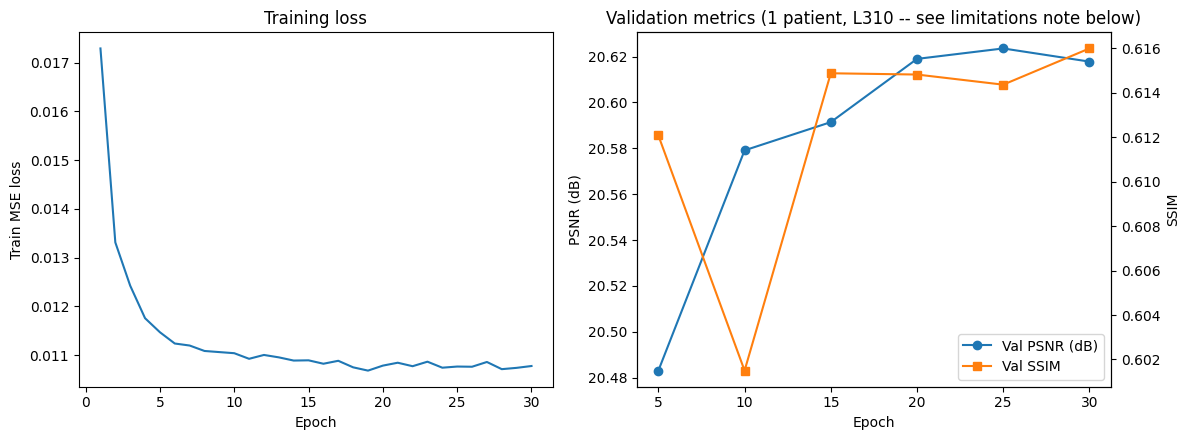

In [13]:
val_epochs = [e for e in range(1, NUM_EPOCHS + 1) if (e % VAL_INTERVAL == 0 or e == NUM_EPOCHS)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(range(1, NUM_EPOCHS + 1), history["train_loss"])
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train MSE loss"); axes[0].set_title("Training loss")

ax2 = axes[1]
ax2.plot(val_epochs, history["val_psnr"], marker="o", color="tab:blue", label="Val PSNR (dB)")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("PSNR (dB)")
ax3 = ax2.twinx()
ax3.plot(val_epochs, history["val_ssim"], marker="s", color="tab:orange", label="Val SSIM")
ax3.set_ylabel("SSIM")
ax2.set_title("Validation metrics (1 patient, L310 -- see limitations note below)")
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="lower right")
plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=120)
plt.show()

## Evaluation on the held-out test patients
- Full 512x512 slices, not training patches -- also a live check that the
  architecture actually generalizes to a size it never trained on.

In [14]:
_, _, test_metrics = evaluate(model, test_ds)

psnr_before_arr = np.array(test_metrics["psnr_before"])
psnr_after_arr  = np.array(test_metrics["psnr_after"])
ssim_before_arr = np.array(test_metrics["ssim_before"])
ssim_after_arr  = np.array(test_metrics["ssim_after"])
patient_arr     = np.array(test_metrics["patient_id"])
test_patients   = sorted(set(patient_arr))

print(f"\nTest set: {len(psnr_after_arr)} slices from {test_patients}")
print(f"PSNR: {psnr_before_arr.mean():.2f} +/- {psnr_before_arr.std():.2f} dB (input) "
      f"-> {psnr_after_arr.mean():.2f} +/- {psnr_after_arr.std():.2f} dB (RED-CNN)")
print(f"SSIM: {ssim_before_arr.mean():.4f} +/- {ssim_before_arr.std():.4f} (input) "
      f"-> {ssim_after_arr.mean():.4f} +/- {ssim_after_arr.std():.4f} (RED-CNN)")

print("\nPer-patient breakdown (test set is only 2 patients -- worth looking at "
      "separately, not just pooled, given how small that n is):")
for pid in test_patients:
    mask = patient_arr == pid
    print(f"  {pid} (n={mask.sum()}): "
          f"PSNR {psnr_before_arr[mask].mean():.2f} -> {psnr_after_arr[mask].mean():.2f} dB, "
          f"SSIM {ssim_before_arr[mask].mean():.4f} -> {ssim_after_arr[mask].mean():.4f}")


Test set: 1136 slices from [np.str_('L333'), np.str_('L506')]
PSNR: 16.60 +/- 1.57 dB (input) -> 22.27 +/- 1.57 dB (RED-CNN)
SSIM: 0.7462 +/- 0.0492 (input) -> 0.7739 +/- 0.0490 (RED-CNN)

Per-patient breakdown (test set is only 2 patients -- worth looking at separately, not just pooled, given how small that n is):
  L333 (n=610): PSNR 15.89 -> 21.78 dB, SSIM 0.7194 -> 0.7493
  L506 (n=526): PSNR 17.42 -> 22.83 dB, SSIM 0.7773 -> 0.8024


## Statistical framing
- A naive paired t-test / bootstrap CI over all 1136 slices is **not valid**
  here and is deliberately not used. Slices from the same patient scan
  aren't independent samples -- they share anatomy, body habitus, and noise
  characteristics. Treating 1136 clustered slices as 1136 i.i.d. observations
  massively overstates the effective sample size: for a claim about
  generalizing to an unseen patient, the real number of independent units
  is 2 (the test patients), not 1136.

In [15]:
psnr_diff = psnr_after_arr - psnr_before_arr
per_patient_gain = {
    pid: float((psnr_after_arr[patient_arr == pid] - psnr_before_arr[patient_arr == pid]).mean())
    for pid in test_patients
}

print("\nWithin-patient slice-level spread (descriptive only -- NOT a between-patient CI):")
print(f"  Mean PSNR improvement, pooled across slices: {psnr_diff.mean():.2f} dB "
      f"(slice-level std: {psnr_diff.std():.2f} dB)")
print("  This says the improvement is consistent slice-to-slice within these 2")
print("  patients' scans. It says nothing valid about a new, unseen patient.")

print("\nPer-patient PSNR improvement (the actual independent units available, n=2):")
for pid, gain in per_patient_gain.items():
    print(f"  {pid}: +{gain:.2f} dB")
print("  With n=2 independent patients, no p-value or confidence interval on")
print("  between-patient generalization is statistically meaningful. That would")
print("  require evaluating on more held-out patients than this 10-patient")
print("  dataset can spare without also shrinking the training set further.")


Within-patient slice-level spread (descriptive only -- NOT a between-patient CI):
  Mean PSNR improvement, pooled across slices: 5.67 dB (slice-level std: 0.39 dB)
  This says the improvement is consistent slice-to-slice within these 2
  patients' scans. It says nothing valid about a new, unseen patient.

Per-patient PSNR improvement (the actual independent units available, n=2):
  L333: +5.89 dB
  L506: +5.42 dB
  With n=2 independent patients, no p-value or confidence interval on
  between-patient generalization is statistically meaningful. That would
  require evaluating on more held-out patients than this 10-patient
  dataset can spare without also shrinking the training set further.


## Classical baseline comparison

In [16]:
print(f"\nRunning classical baselines on a subsample of the test set "
      f"(n={CLASSICAL_BASELINE_SAMPLES}, NLM is slow on full 512x512 slices)...")
classical_results, classical_idx = classical_baselines(test_ds, CLASSICAL_BASELINE_SAMPLES)
n_classical = len(classical_idx)


def summarize(arr):
    arr = np.asarray(arr)
    return arr.mean(), arr.std()


# Compare all methods on the exact same subsample for a fair comparison
sub_psnr_before, sub_psnr_after = psnr_before_arr[classical_idx], psnr_after_arr[classical_idx]
sub_ssim_before, sub_ssim_after = ssim_before_arr[classical_idx], ssim_after_arr[classical_idx]

comparison_rows = [
    ("Low-dose input (no processing)", *summarize(sub_psnr_before), *summarize(sub_ssim_before)),
    ("Gaussian filter (sigma=1)", *summarize(classical_results["gaussian"]["psnr"]),
     *summarize(classical_results["gaussian"]["ssim"])),
    ("Non-local means (skimage)", *summarize(classical_results["nlm"]["psnr"]),
     *summarize(classical_results["nlm"]["ssim"])),
    ("RED-CNN (this model)", *summarize(sub_psnr_after), *summarize(sub_ssim_after)),
]
comparison_df = pd.DataFrame(comparison_rows,
                              columns=["Method", "PSNR mean", "PSNR std", "SSIM mean", "SSIM std"])
comparison_df.insert(1, "N slices", n_classical)
print(f"\nMethod comparison, matched subsample (n={n_classical} slices, identical slices in every row):")
print(comparison_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print("\nNote on comparing to published numbers: PSNR is not scale-invariant across")
print("papers -- the same underlying noise gives very different PSNR depending on the")
print("HU window used (a 400 HU window vs a 3000 HU window differs by ~17-18 dB for")
print("identical image quality, confirmed algebraically: PSNR scales as 20*log10(window")
print("width) for fixed noise). Treat any gap from a published ~33-44 dB RED-CNN figure")
print("as mostly a normalization artifact unless that figure uses an identical window.")


Running classical baselines on a subsample of the test set (n=200, NLM is slow on full 512x512 slices)...

Method comparison, matched subsample (n=200 slices, identical slices in every row):
                        Method  N slices  PSNR mean  PSNR std  SSIM mean  SSIM std
Low-dose input (no processing)       200     16.606     1.578      0.747     0.049
     Gaussian filter (sigma=1)       200     20.822     1.386      0.726     0.052
     Non-local means (skimage)       200     20.171     1.395      0.751     0.056
          RED-CNN (this model)       200     22.274     1.577      0.774     0.049

Note on comparing to published numbers: PSNR is not scale-invariant across
papers -- the same underlying noise gives very different PSNR depending on the
HU window used (a 400 HU window vs a 3000 HU window differs by ~17-18 dB for
identical image quality, confirmed algebraically: PSNR scales as 20*log10(window
width) for fixed noise). Treat any gap from a published ~33-44 dB RED-CNN figure

## Qualitative comparison
- Worst 3 slices are picked by absolute post-model PSNR, not by improvement
  -- "where does the model's output end up worst in absolute terms" is the
  more clinically relevant question than "where did it gain the least."


Worst 3 slices by absolute post-model PSNR:
  index 691 (patient L506): PSNR 18.09 dB, SSIM 0.6821
  index 688 (patient L506): PSNR 18.15 dB, SSIM 0.6806
  index 685 (patient L506): PSNR 18.22 dB, SSIM 0.6837


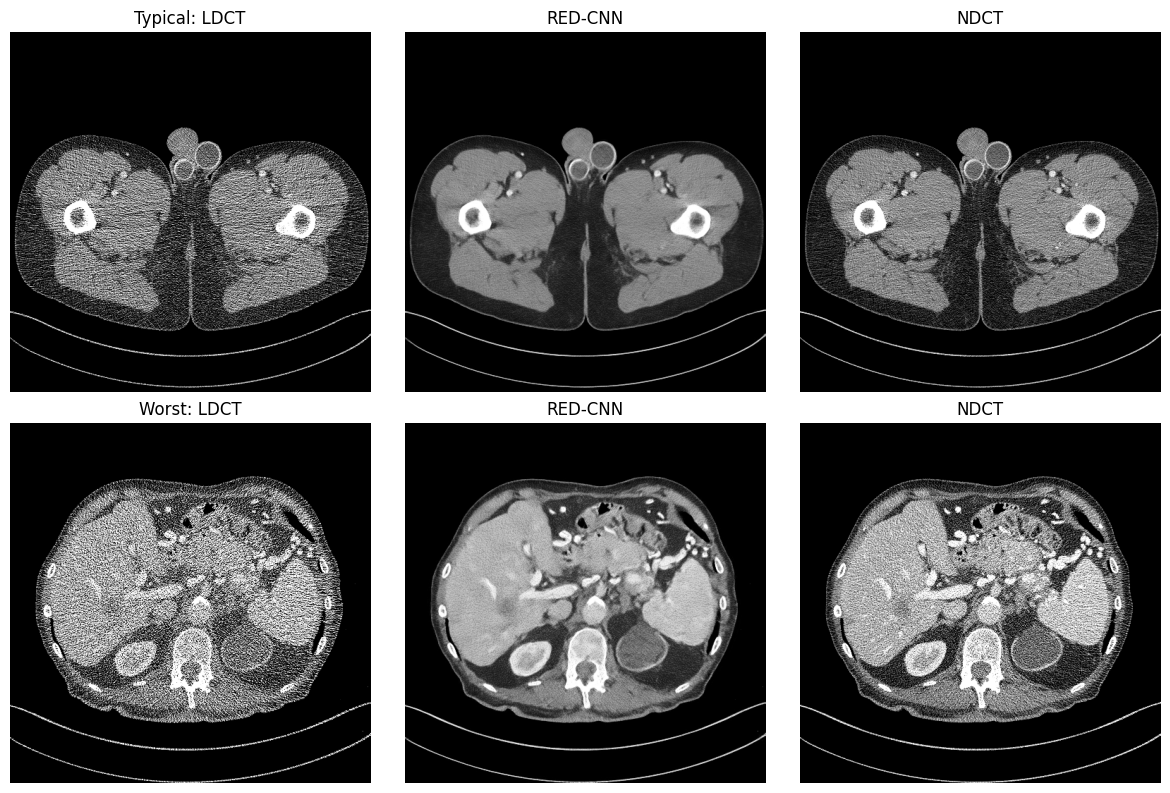

In [17]:
worst_indices = np.argsort(psnr_after_arr)[:3]
typical_index = len(test_ds.images) // 2

print("\nWorst 3 slices by absolute post-model PSNR:")
for i in worst_indices:
    print(f"  index {i} (patient {test_ds.images[i][2]}): "
          f"PSNR {psnr_after_arr[i]:.2f} dB, SSIM {ssim_after_arr[i]:.4f}")

typical_input, typical_target, typical_pred = predict_one(model, test_ds, typical_index)
worst_input, worst_target, worst_pred = predict_one(model, test_ds, int(worst_indices[0]))

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes[0, 0].imshow(typical_input, cmap="gray");  axes[0, 0].set_title("Typical: LDCT")
axes[0, 1].imshow(typical_pred, cmap="gray");   axes[0, 1].set_title("RED-CNN")
axes[0, 2].imshow(typical_target, cmap="gray"); axes[0, 2].set_title("NDCT")

axes[1, 0].imshow(worst_input, cmap="gray");  axes[1, 0].set_title("Worst: LDCT")
axes[1, 1].imshow(worst_pred, cmap="gray");   axes[1, 1].set_title("RED-CNN")
axes[1, 2].imshow(worst_target, cmap="gray"); axes[1, 2].set_title("NDCT")

for row in axes:
    for ax in row:
        ax.axis("off")
plt.tight_layout()
plt.savefig("/kaggle/working/comparison.png", dpi=120)
plt.show()

## Known limitations (short version -- see README.md for the full discussion with this run's actual numbers)
- Validation is 1 patient (533 slices) -- checkpoint selection and the learning-rate
  comparison during development were both tuned against that one patient's anatomy.
- Train/val/test is a single fixed split, not leave-one-patient-out cross-validation
  as in the original paper -- a deliberate cost/rigor tradeoff, not an oversight.
- Classical baselines use skimage's default rule-of-thumb parameters, not exhaustively tuned.
- "Quarter dose" is simulated (Poisson noise added to full-dose projections), not an
  independent lower-dose acquisition.
- MSE loss is known to over-smooth fine structure; PSNR/SSIM can disagree with each
  other and don't fully capture diagnostic usefulness.
- Receptive field is ~21x21 pixels (5 layers, 5x5 kernels, no pooling) -- a plausible
  structural limit on how much anatomical context the model can use.

In [18]:
print("\nSee README.md for the full discussion of known limitations, with "
      "this run's actual numbers, before citing results elsewhere.")


See README.md for the full discussion of known limitations, with this run's actual numbers, before citing results elsewhere.
